In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares, curve_fit
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt

from treament_tcspc_data import fetch_data_filenames, extract_data_info_from_path, time_domain_visual_verification
# from snr_aux_functions import get_snr_db, plot_time_and_freq_domain

In [2]:
#--------------------------------------
# Dados experimentais (freq, phase_difference, ph_diff_error)
#--------------------------------------
pd = np.load("./phase_difference_list.npy")
w_list = np.load("./w_list.npy")

#--------------------------------------
# Estimativa de n1 e n4
#--------------------------------------
dens_y2o3 = 5.010 #g/cm^3
massa_molar_y2o3 = 225.81 #g/mol
frac_er = 0.005 # percentual de Er3+ da amostra no experimento
frac_yb = 0.015 # percentual de Yb3+ da amostra no experimento

n1 = (dens_y2o3/massa_molar_y2o3)*(6.022e23)*2*(frac_er)
n4 = (dens_y2o3/massa_molar_y2o3)*(6.022e23)*2*(frac_yb)

#--------------------------------------
# Parâmetros inseridos
#--------------------------------------
k21 = 16.66   # Tab. 2 em https://doi.org/10.1063/1.2739301
k54 = 1279.0  # Tab. 2 Lu0 em https://doi.org/10.1016/j.jallcom.2021.159227
sigma = 1.75e-20 # # Supporting Information, page S5, Labrador

P = 5.4e20    # fótons / (cm^2 * s) (baseado em 110 W/cm^2 do paper de Labrador)

#====================================================
# Constantes depois do ajuste de eq. 18
#====================================================
k31 = 17237.7 # s^-1
ww51 = 8.192933479247868e-09 # chute incial
ww52 = 1.9970817793515877e-07 # chute inicial
#====================================================

#====================================================
# Dados de meus experimentos
#====================================================
amplitude = 0.5
offset = 0.8
#====================================================

In [7]:
# 3. Função para Extrair a Fase via FFT
def extrair_fase(t, n3, freq):
    # DICA CRUCIAL: Descartar a primeira metade da simulação (o transiente)
    # Analisamos apenas a parte onde a onda já estabilizou
    meio = len(t) // 2
    t_estavel = t[meio:]
    n3_estavel = n3[meio:]
    
    # Recria o sinal do laser no mesmo intervalo de tempo para comparação
    laser_estavel = offset + amplitude * np.cos(2 * np.pi * freq * t_estavel)
    
    N = len(t_estavel)
    dt = t_estavel[1] - t_estavel[0]
    
    # Aplica a FFT
    yf_n3 = fft(n3_estavel)
    yf_laser = fft(laser_estavel)
    xf = fftfreq(N, dt)
    
    # Encontra o índice da frequência de modulação (freq) no array da FFT
    idx = np.argmin(np.abs(xf - freq))
    
    # Extrai o ângulo (fase) de ambos os sinais nesse pico de frequência
    fase_n3 = np.angle(yf_n3[idx])
    fase_laser = np.angle(yf_laser[idx])
    
    # Diferença de fase (Luminescência - Laser)
    delta_fase = fase_n3 - fase_laser
    
    # Garante que o valor fique no intervalo correto [-pi, pi]
    delta_fase = np.angle(np.exp(1j * delta_fase))
    
    return delta_fase

# Ajustando novos parâmetros
wp51 = lambda f, W51: W51*n1/f
wp52 = lambda f, W52: W52*n1/f
kp21 = lambda f: k21/f
kp31 = lambda f: k31/f
kp45 = lambda f: sigma*P/f
kp54 = lambda f: k54/f
x4 = n4/n1


Processing particle 1, which has W51=7.3e-09 and W52=3.4e-07


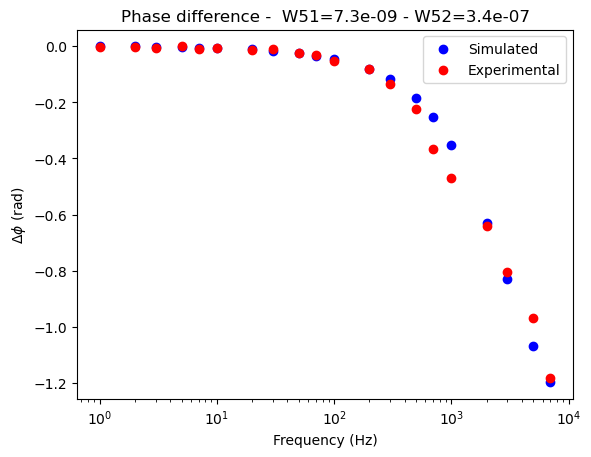

Processing particle 2, which has W51=2e-08 and W52=4e-07


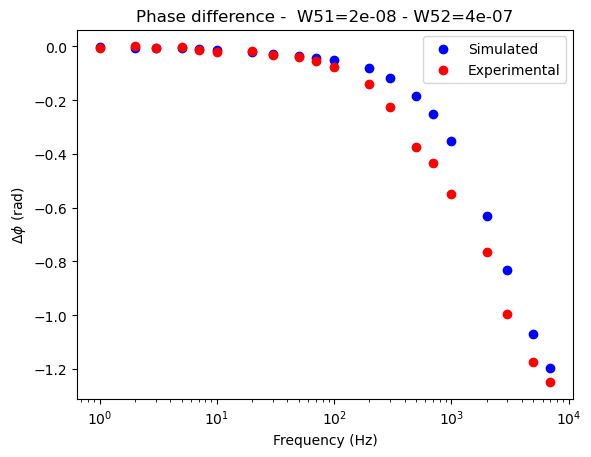

Processing particle 3, which has W51=8.5e-09 and W52=2.2e-07


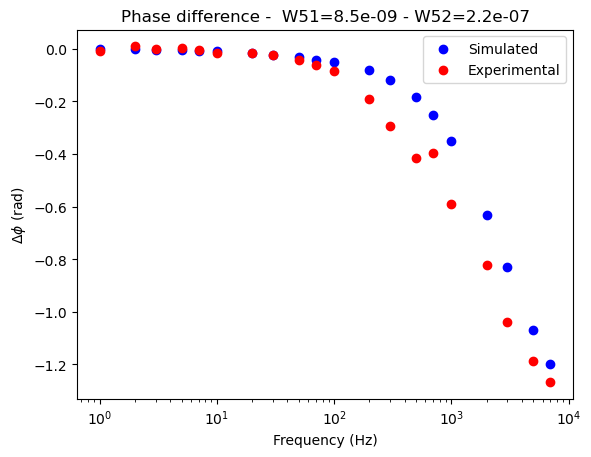

Processing particle 4, which has W51=1.9e-08 and W52=3.6e-07


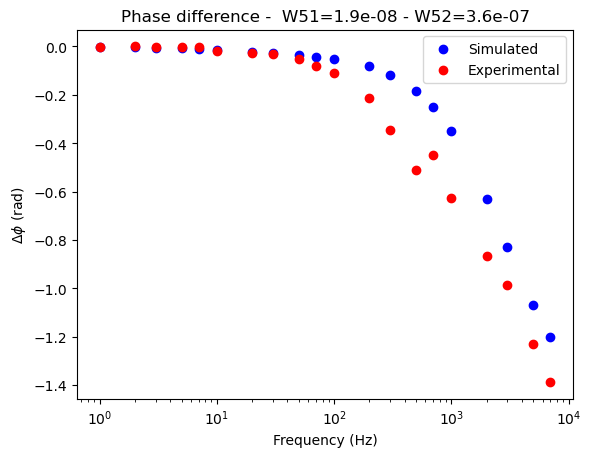

Processing particle 5, which has W51=1.6e-08 and W52=3.4e-07


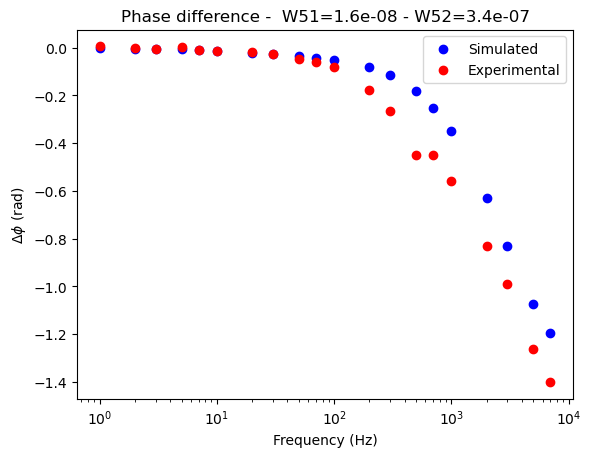

Processing particle 6, which has W51=1.3e-08 and W52=4.4e-07


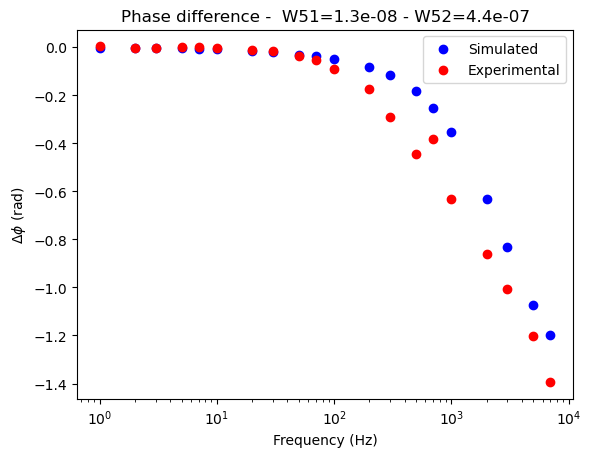

Processing particle 7, which has W51=1.8e-08 and W52=3.3e-07


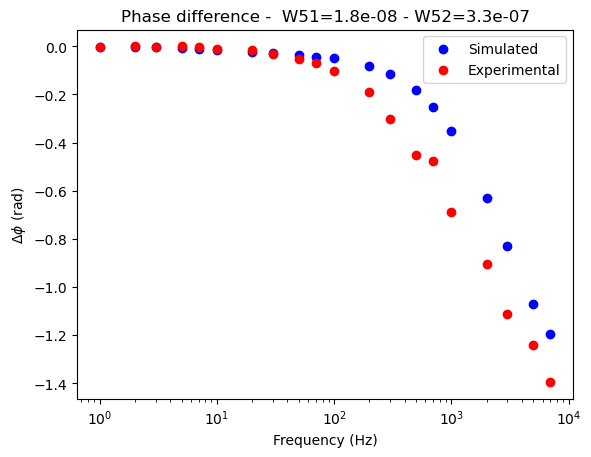

Processing particle 8, which has W51=1.8e-08 and W52=3.7e-07


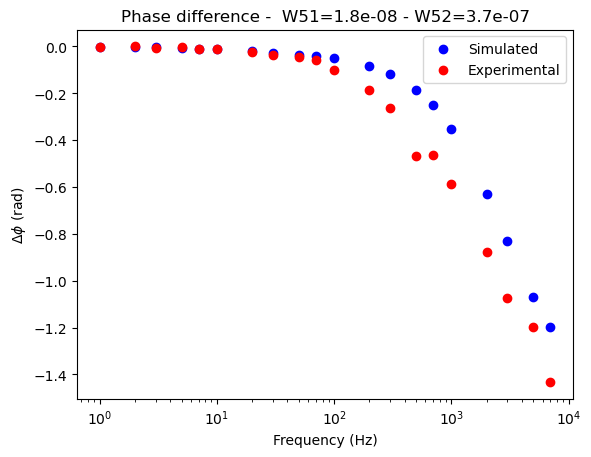

Processing particle 9, which has W51=1.7e-08 and W52=4e-07


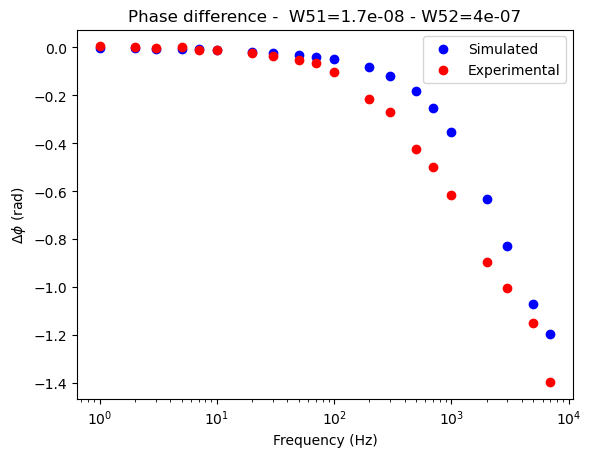

Processing particle 10, which has W51=1.8e-08 and W52=3.6e-07


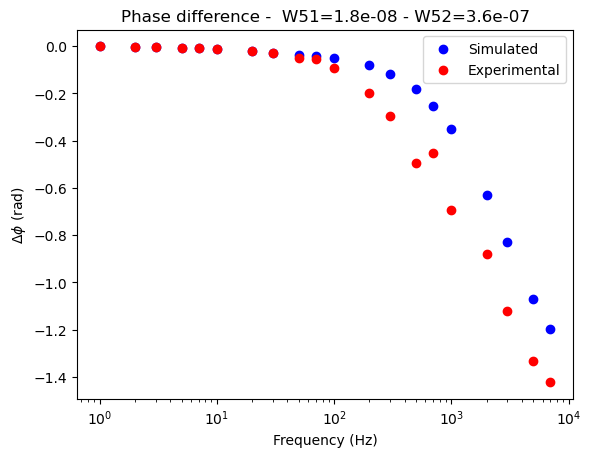

Processing particle 11, which has W51=1.7e-08 and W52=3.8e-07


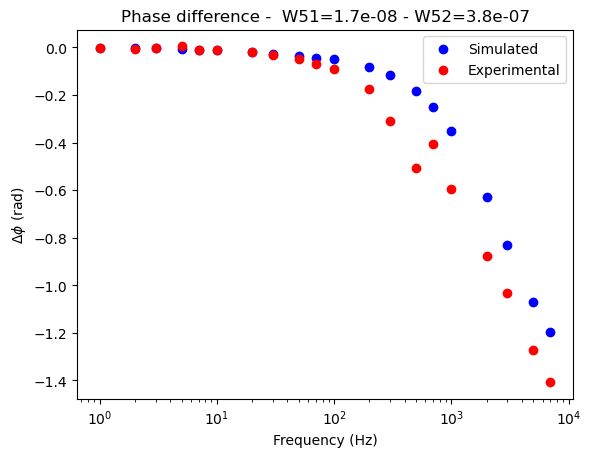

Processing particle 12, which has W51=1.4e-08 and W52=3.6e-07


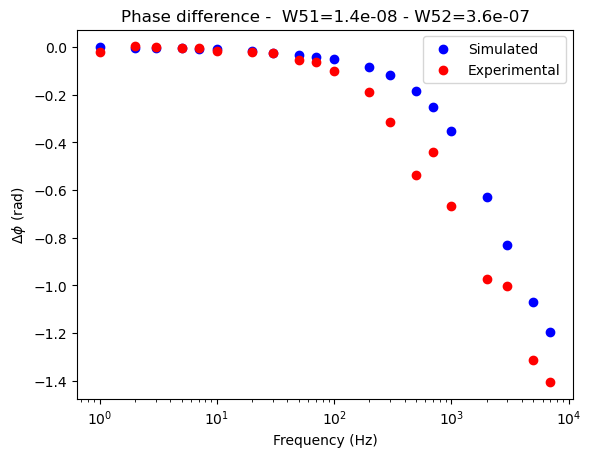

Processing particle 13, which has W51=9.8e-09 and W52=2.3e-07


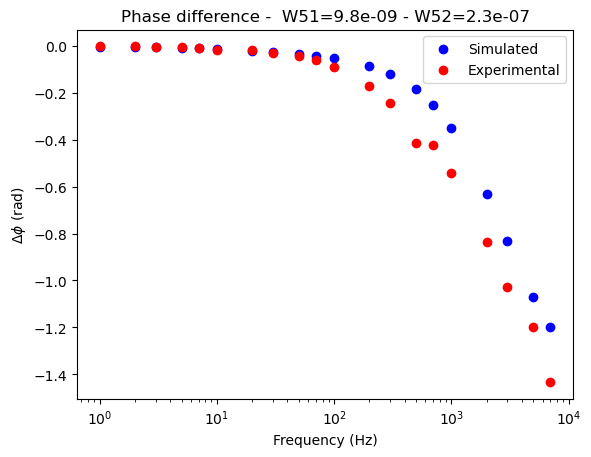

Processing particle 14, which has W51=1.8e-08 and W52=3.8e-07


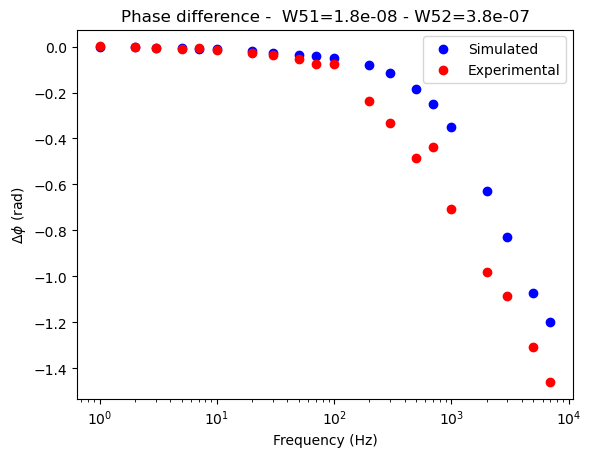

Processing particle 15, which has W51=8.3e-09 and W52=2.1e-07


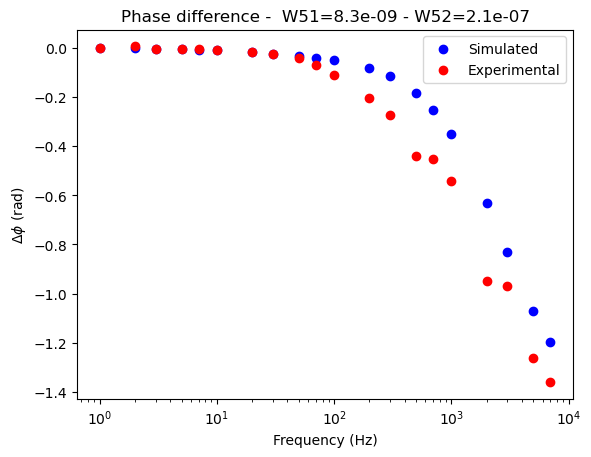

Processing particle 16, which has W51=8.2e-09 and W52=2e-07


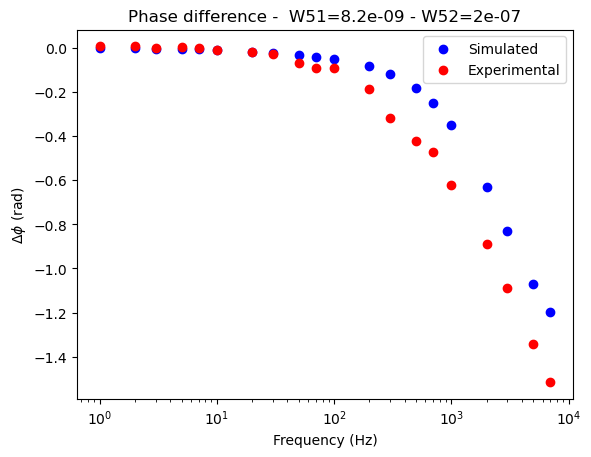

Processing particle 17, which has W51=8.1e-09 and W52=2.2e-07


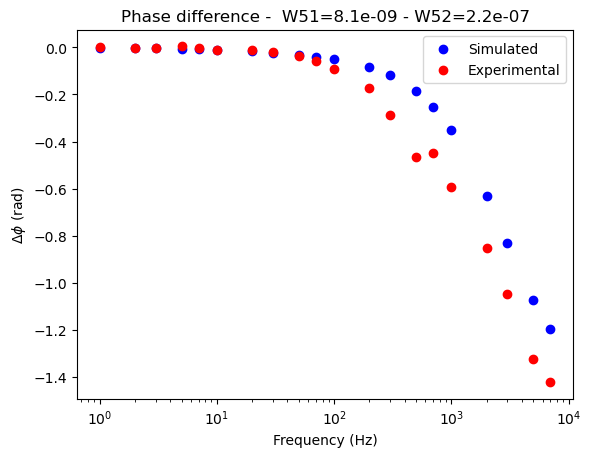

Processing particle 18, which has W51=8.2e-09 and W52=2.2e-07


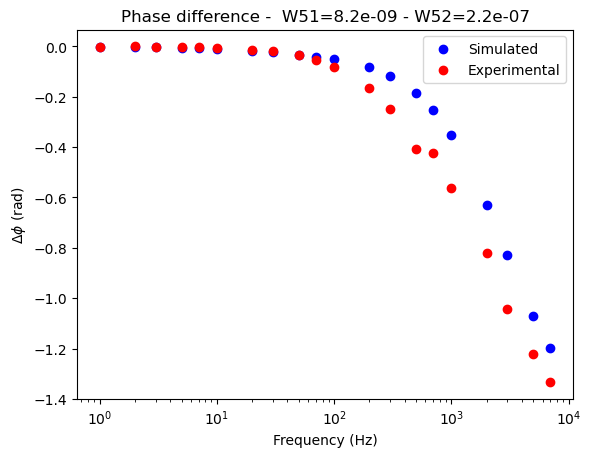

Processing particle 19, which has W51=1.7e-08 and W52=3.9e-07


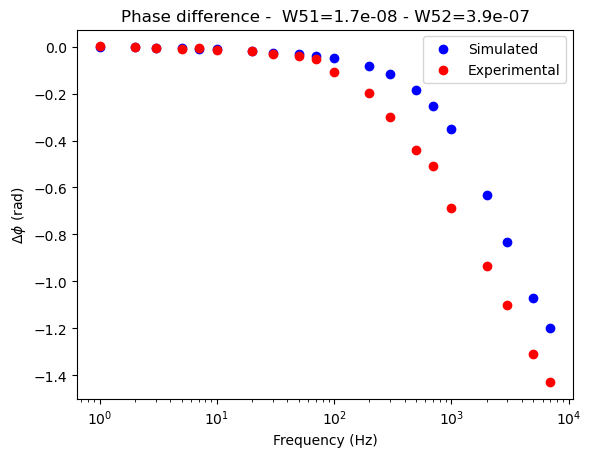

Processing particle 20, which has W51=8.2e-09 and W52=2.1e-07


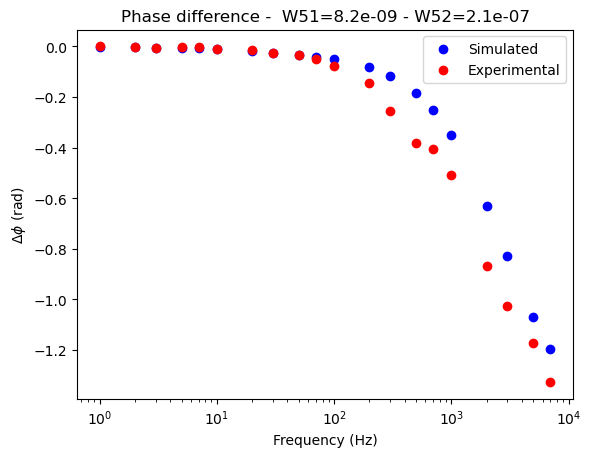

Processing particle 21, which has W51=1.6e-08 and W52=4.7e-07


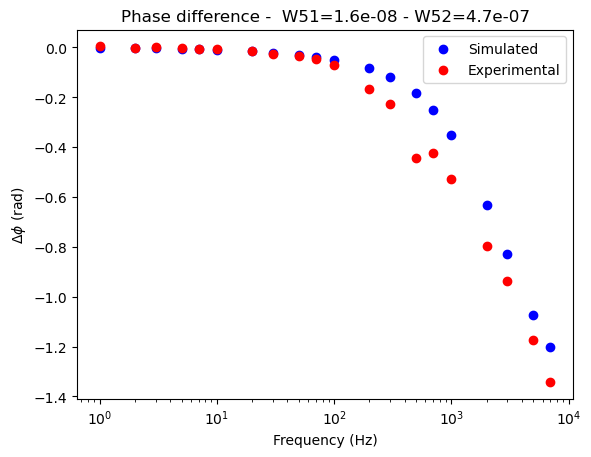

Processing particle 22, which has W51=1.1e-08 and W52=3.1e-07


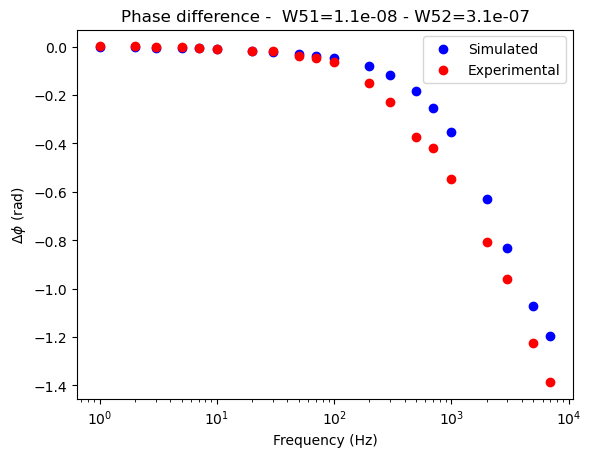

Processing particle 23, which has W51=1.3e-08 and W52=2.3e-07


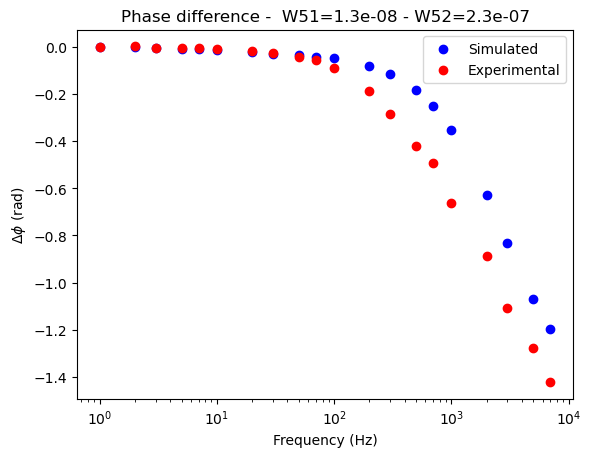

Processing particle 24, which has W51=1.7e-08 and W52=3.8e-07


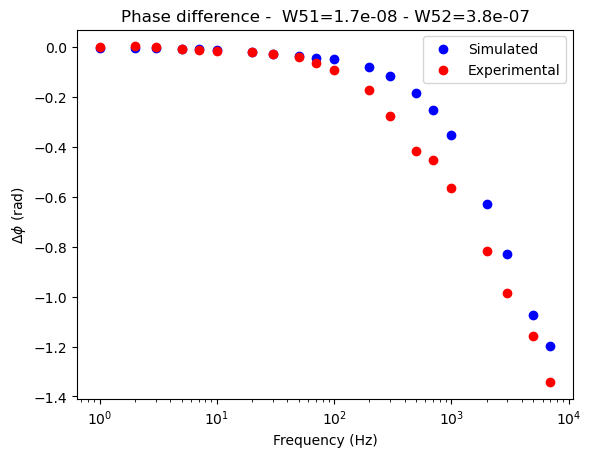

Processing particle 25, which has W51=8.3e-09 and W52=2.2e-07


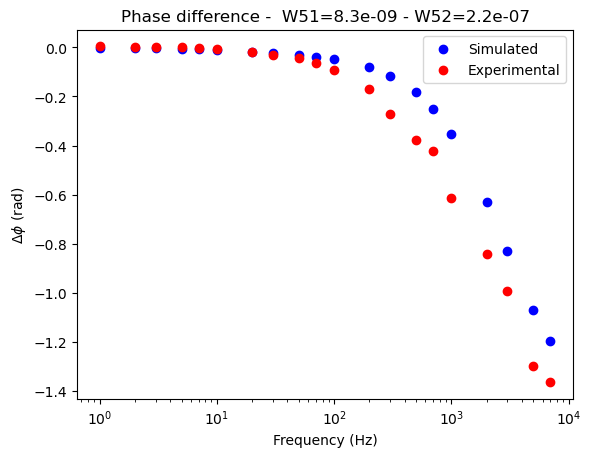

Processing particle 26, which has W51=1.3e-08 and W52=2.7e-07


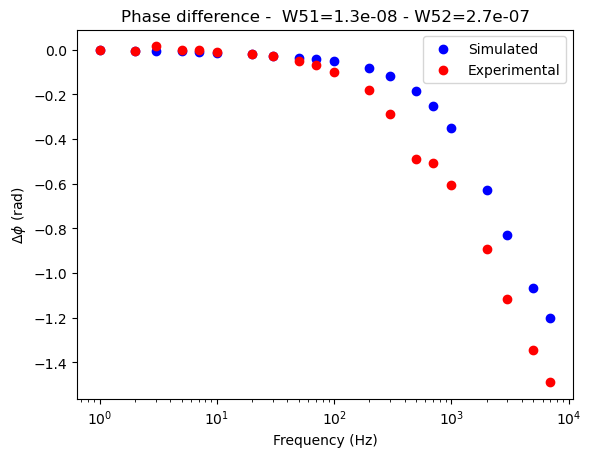

Processing particle 27, which has W51=1.6e-08 and W52=3.3e-07


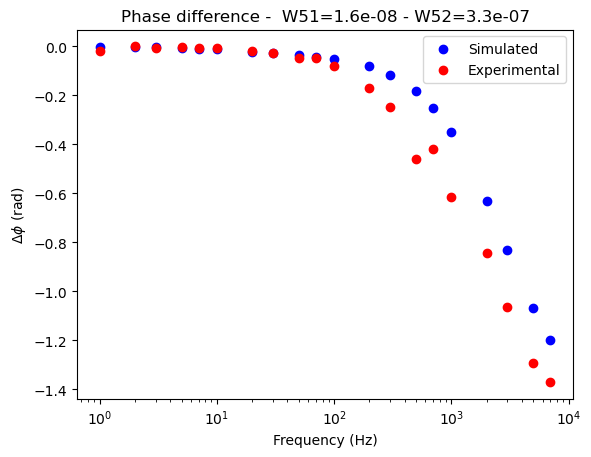

Processing particle 28, which has W51=8.2e-09 and W52=2.7e-07


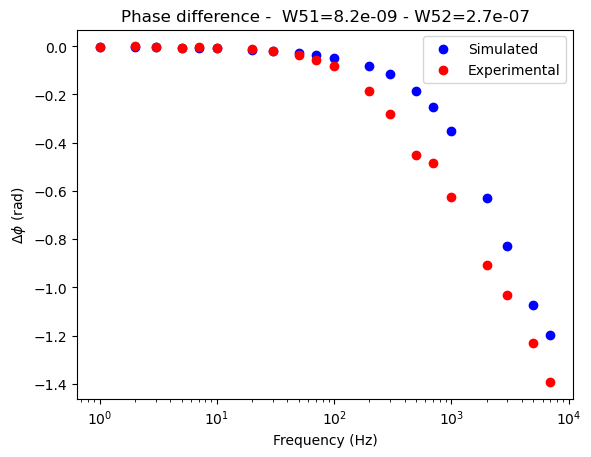

Processing particle 29, which has W51=9.6e-09 and W52=1.7e-07


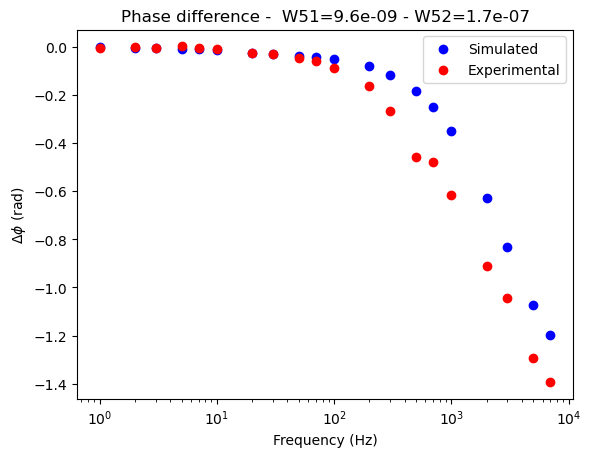

Processing particle 30, which has W51=1.1e-08 and W52=2.3e-07


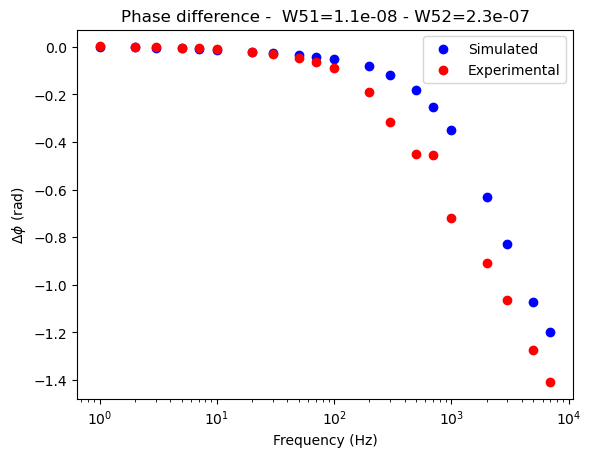

In [9]:
def odes(t, x, W51, W52, freq):
    # o t agora é tau
    x5, x2, x3 = x
    
    # Função do laser conforme seus dados experimentais
    F_t = offset + amplitude * np.cos(2*np.pi * t)
    
    # Prevenção numérica: a intensidade não pode ser negativa
    if F_t < 0: F_t = 0.0 

    dx5_dt = kp45(freq) * F_t * x4 - wp51(freq, W51) * x5 - wp52(freq, W52) * x2 * x5 - kp54(freq) * x5
    dx2_dt = wp51(freq, W51) * x5 - wp52(freq, W52) * x2 * x5 - kp21(freq) * x2
    dx3_dt = wp52(freq, W52) * x2 * x5 - kp31(freq) * x3
    return [dx5_dt, dx2_dt, dx3_dt]

for i in range(len(pd)):
    ww51, ww52 = w_list[i]

    print("==================================================")
    print(f"Processing particle {i+1}, which has W51={ww51:.2} and W52={ww52:.2}") 
    print("==================================================")
    pd_simulated = []
    num_points = 20 #len(pd)

    for freq in pd[i,:num_points, 0]:
        #define as EDOS
        t_span = (0, 200) # Simula 200 ciclos

        x0 = [0, 0, 0] # x5, x2, x3
        t_eval = np.linspace(t_span[0], t_span[-1], 10000)
        sol = solve_ivp(
            odes, 
            t_span, 
            x0, 
            t_eval=t_eval,
            args=(ww51, ww52, freq),
            method="Radau"
            )
        n3 = (sol.y[2])*n1 # Retorna a dimensão correta em cm^-3
        ts = (sol.t)*(1/freq) # Retorna a dimensão correta em s

        pd_simulated.append(
            [freq, extrair_fase(ts, n3, freq)]
            )

    pd_simulated = np.array(pd_simulated)

    ## Fazer plots comparando experimento e simulação
    # _, axs = plt.subplots(1,2, figsize=(15,5))
    plt.scatter(pd_simulated[:,0], np.unwrap(pd_simulated[:,1]), color="blue", label="Simulated")
    plt.scatter(pd[i,:num_points,0], pd[i,:num_points,1], color="red", label="Experimental")
    plt.title("Phase difference - " + f" W51={ww51:.2} - W52={ww52:.2}")
    plt.ylabel("$\Delta \phi$ (rad)")
    plt.xlabel("Frequency (Hz)")
    plt.xscale("log")
    plt.legend(loc="best")
    plt.show()

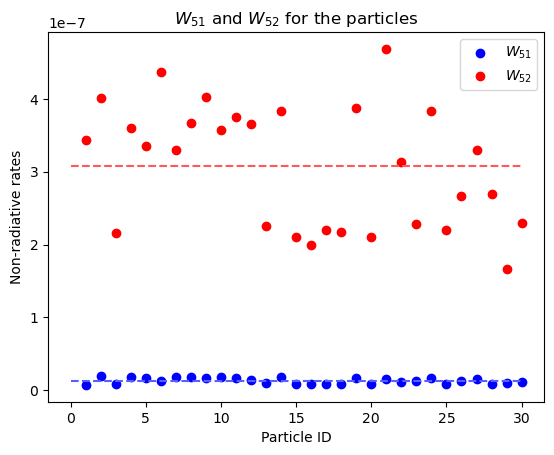

In [32]:
plt.scatter([(i+1) for i in range(len(w_list))], w_list[:,0], color="blue", label="$W_{51}$")
plt.scatter([(i+1) for i in range(len(w_list))], w_list[:,1], color="red", label="$W_{52}$")
plt.hlines(w_list[:, 0].mean(), xmin=0, xmax=30, color="#5560ffff", linestyles="--")
plt.hlines(w_list[:, 1].mean(), xmin=0, xmax=30, color="#ff5858ff", linestyles="--")
plt.legend()
plt.ylabel("Non-radiative rates")
plt.xlabel("Particle ID")
plt.title("$W_{51}$ and $W_{52}$ for the particles")
plt.show()

In [34]:
(w_list[:, 1].mean())/(w_list[:, 0].mean())

np.float64(23.304681195263015)